The dataset was inspected for missing values and duplicate rows before preprocessing. No substantial missingness was observed, and the dataset was then prepared by encoding categorical variables and generating stratified train, validation, and test splits.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
processed_dir = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed")
print(processed_dir.exists())

True


In [4]:
df_paysim_clean = pd.read_csv(processed_dir / "paysim_clean.csv")
print(df_paysim_clean.shape)
df_paysim_clean.head()

(6362620, 12)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,sample_id
0,1,3,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0
1,1,3,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,4,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,2
3,1,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,3
4,1,3,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,4


In [24]:
df_paysim_clean.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'sample_id']

In [4]:
import matplotlib.pyplot as plt

def plot_class_distribution(df):
    class_counts = df["isFraud"].value_counts().sort_index()

    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.xticks([0, 1], ["Non-Fraud", "Fraud"], rotation=0)
    plt.ylabel("Number of transactions")
    plt.title("Class distribution of the PaySim dataset")
    plt.tight_layout()
    plt.show()

def plot_transaction_type_distribution(df):
    type_counts = df["type"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    type_counts.plot(kind="bar")
    plt.ylabel("Number of transactions")
    plt.title("Transaction type distribution in PaySim")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

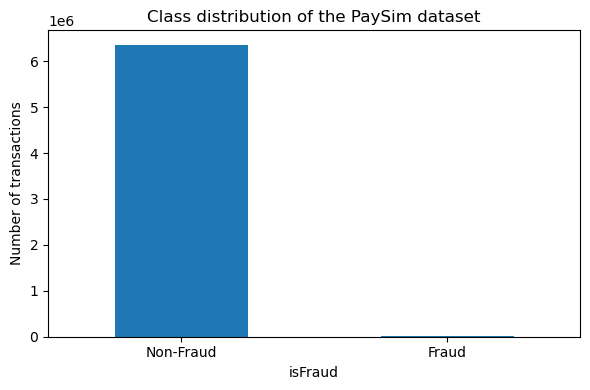

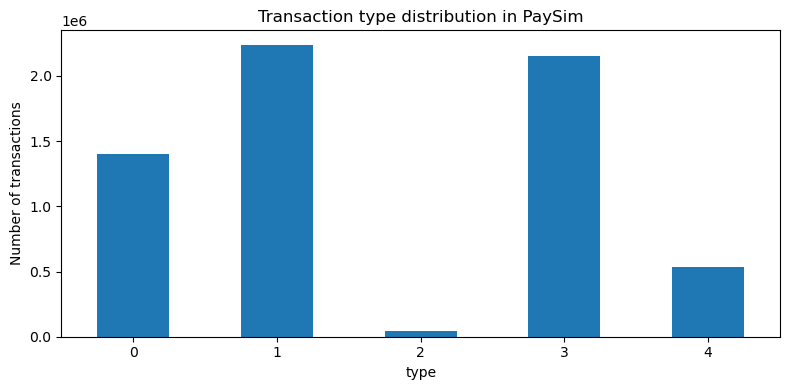

In [5]:
plot_class_distribution(df_paysim_clean)
plot_transaction_type_distribution(df_paysim_clean)

In [6]:
type_map_reverse = {
    0: "CASH_IN",
    1: "CASH_OUT",
    2: "DEBIT",
    3: "PAYMENT",
    4: "TRANSFER"
}

def plot_transaction_type_distribution_named(df):
    type_counts = df["type"].value_counts().sort_index()
    labels = [type_map_reverse[i] for i in type_counts.index]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, type_counts.values)
    plt.ylabel("Number of transactions")
    plt.title("Transaction type distribution in PaySim")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

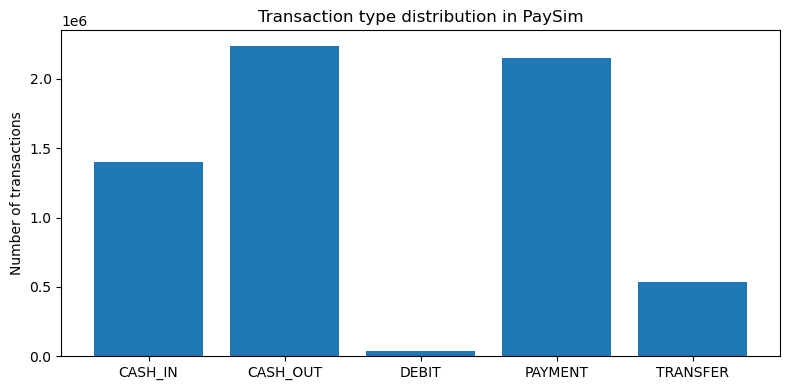

In [7]:
plot_transaction_type_distribution_named(df_paysim_clean)

In [8]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

paysim_full = pd.concat([paysim_train, paysim_val, paysim_test], ignore_index=True)

print("Train:", paysim_train.shape)
print("Validation:", paysim_val.shape)
print("Test:", paysim_test.shape)
print("Full:", paysim_full.shape)

Train: (4453834, 12)
Validation: (636262, 12)
Test: (1272524, 12)
Full: (6362620, 12)


In [9]:
print("Columns:")
print(paysim_full.columns.tolist())

print("\nData types:")
print(paysim_full.dtypes)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'sample_id']

Data types:
step                int64
type                int64
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
sample_id           int64
dtype: object


In [10]:
missing = paysim_full.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:")
print(missing if len(missing) > 0 else "No missing values")

Missing values:
No missing values


In [11]:
target_counts = paysim_full["isFraud"].value_counts().sort_index()
target_percent = paysim_full["isFraud"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(4)
})

target_summary

,count,percent
isFraud,,
0,6354407,99.8709
1,8213,0.1291
